# Real Data Performance

This notebook compares the performance of the EM approach to LOOCV approach using real-world datasets.

## Preview Experiment

In [1]:
import numpy as np
import pandas as pd

from fastridge import RidgeEM, RidgeLOOCV
from experiments import EmpiricalDataExperiment
from problems import EmpiricalDataProblem, OneHotEncodeCategories, PolynomialExpansion

_OHE = [OneHotEncodeCategories()]

problems = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure'),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',   'target'),
    EmpiricalDataProblem('eye',        'y'),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE),
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2'],         x_transforms=_OHE),
    EmpiricalDataProblem('yacht',      'Residuary_resistance'),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE),
]

estimators = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp = EmpiricalDataExperiment(
    problems, list(estimators.values()),
    n_iterations=10, seed=123,
    est_names=list(estimators.keys())).run()
print()

abalone (n=4177, p=9)..........
airfoil (n=1503, p=5)..........
concrete (n=1030, p=8)..........
diabetes (n=442, p=10)..........
eye (n=120, p=200)..........
forest (n=517, p=27)..........
student (n=649, p=39)..........
yacht (n=308, p=6)..........
automobile (n=159, p=51)..........



In [2]:
def stat_mean(exp, stat_name, est_name, problem_idx):
    j = exp.est_names.index(est_name)
    return np.nanmean(getattr(exp, stat_name + '_')[:, problem_idx, 0, j])

rows = []
for i, problem in enumerate(exp.problems):
    em_time = stat_mean(exp, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp, 'prediction_r2', est, i) for est in exp.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp.ns[i, 0])
    row['n:p']      = int(exp.ns[i, 0]) / stat_mean(exp, 'number_of_features', 'EM', i)
    rows.append(row)
pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.51,0.51,0.51,8.79,9.0,2923,324.78
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,11.09,5.0,1052,210.40
2,concrete,Concrete compressive strength,0.60,0.60,0.60,9.23,8.0,721,90.12
6,student,G3,0.26,0.26,0.26,5.89,39.0,454,11.64
5,forest,area,-0.08,-0.09,-0.26,2.55,26.2,361,13.78
3,diabetes,target,0.48,0.48,0.48,7.33,10.0,309,30.90
7,yacht,Residuary_resistance,0.65,0.64,0.64,8.91,6.0,215,35.83
8,automobile,price,0.88,0.85,0.87,5.00,50.2,111,2.21
4,eye,y,0.59,0.34,0.54,1.63,200.0,84,0.42


In [3]:
problems_d2 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('eye',        'y',                             x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2'],         x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE + [PolynomialExpansion(2)]),
]

In [4]:
exp_d2 = EmpiricalDataExperiment(
    problems_d2, list(estimators.values()),
    n_iterations=10, seed=123,
    est_names=list(estimators.keys())).run()
print()

abalone (n=4177, p=54)..........
airfoil (n=1503, p=20)..........
concrete (n=1030, p=44)..........
diabetes (n=442, p=65)..........
eye (n=120, p=20300)..........
forest (n=517, p=405)..........

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(



student (n=649, p=819)..........
yacht (n=308, p=27)..........
automobile (n=159, p=1377)..........



In [5]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time = stat_mean(exp_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_d2, 'prediction_r2', est, i) for est in exp_d2.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d2, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d2.ns[i, 0])
    row['n:p']      = int(exp_d2.ns[i, 0]) / stat_mean(exp_d2, 'number_of_features', 'EM', i)
    rows_d2.append(row)
pd.DataFrame(rows_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.01,0.00,0.00,5.00,53.00,2923,55.15
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,8.84,20.00,1052,52.60
2,concrete,Concrete compressive strength,0.77,0.78,0.77,6.38,44.00,721,16.39
6,student,G3,0.25,-2.24,0.20,1.58,799.00,454,0.57
5,forest,area,-0.08,-0.09,-0.52,0.76,293.33,361,1.23
3,diabetes,target,0.45,0.46,0.45,5.41,65.00,309,4.75
7,yacht,Residuary_resistance,0.92,0.92,0.92,9.44,27.00,215,7.96
8,automobile,price,0.88,-1180.10,0.86,1.50,1008.50,111,0.11
4,eye,y,0.31,0.31,0.31,1.08,20300.00,84,0.00


In [6]:
problems_d3 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=[PolynomialExpansion(3)]),
    # EmpiricalDataProblem('eye',        'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2'],         x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE + [PolynomialExpansion(3)]),
]

In [7]:
exp_d3 = EmpiricalDataExperiment(
    problems_d3, list(estimators.values()),
    n_iterations=10, seed=123,
    est_names=list(estimators.keys())).run()
print()

abalone (n=4177, p=219)..........
airfoil (n=1503, p=55)..........
concrete (n=1030, p=164)..........
diabetes (n=442, p=285)..........
forest (n=517, p=4059)..........
student (n=649, p=11479)..........
yacht (n=308, p=83)..........
automobile (n=159, p=24803)..........



In [8]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time = stat_mean(exp_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_d3, 'prediction_r2', est, i) for est in exp_d3.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d3, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d3.ns[i, 0])
    row['n:p']      = int(exp_d3.ns[i, 0]) / stat_mean(exp_d3, 'number_of_features', 'EM', i)
    rows_d3.append(row)
pd.DataFrame(rows_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,-2.22,-2.00,-2.03,3.02,209.0,2923,13.99
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,5.58,55.0,1052,19.13
2,concrete,Concrete compressive strength,0.84,0.85,0.85,3.21,164.0,721,4.40
5,student,G3,0.22,-0.45,-0.44,0.93,10545.0,454,0.04
4,forest,area,-0.08,-445.27,-1.53,0.32,1939.6,361,0.19
3,diabetes,target,0.40,0.40,0.40,2.50,285.0,309,1.08
6,yacht,Residuary_resistance,0.99,0.99,0.97,5.28,83.0,215,2.59
7,automobile,price,0.86,-630.86,0.80,0.66,12079.1,111,0.01


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar

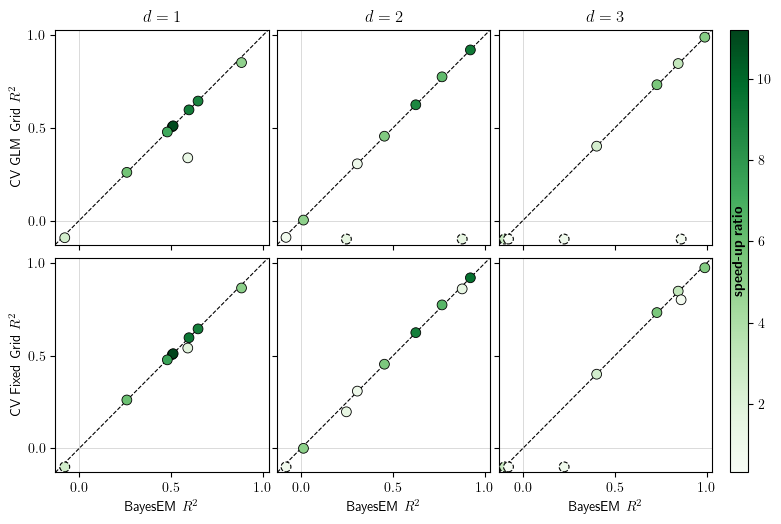

In [10]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp, exp_d2, exp_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp, exp_d2, exp_d3]):
    for row, cv in enumerate([1, 2]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


## Full Experiment: Small and Moderately-sized Datasets

This experiment corresponds to Figure 3 of the appendix.

In [11]:
problems_full = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure'),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows'),  # could include brand part of car name for increasing p
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols'),
    EmpiricalDataProblem('ribo',             'y'),
    EmpiricalDataProblem('eye',              'y'),
    EmpiricalDataProblem('boston',           'medv'),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',         'target'),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows',                      x_transforms=_OHE),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE),
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay']),  # 'Ts', 'Tp' could be extra targets, but dropping reduces r2
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay']),  # 'Ts', 'Tp' could be extra targets, but dropping reduces r2
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS']),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS']),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area'),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2'],         x_transforms=_OHE),
    EmpiricalDataProblem('yacht',            'Residuary_resistance'),
]

estimators_full = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp_full = EmpiricalDataExperiment(
    problems_full, list(estimators_full.values()),
    n_iterations=100, seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone (n=4177, p=9)....................................................................................................
airfoil (n=1503, p=5)....................................................................................................
automobile (n=159, p=51)....................................................................................................
autompg (n=392, p=7)....................................................................................................
crime (n=1994, p=99)....................................................................................................
ribo (n=71, p=4088)....................................................................................................
eye (n=120, p=200)....................................................................................................
boston (n=506, p=13)....................................................................................................
concrete (n=1030, p=8).......

In [12]:
rows_full = []
for i, problem in enumerate(exp_full.problems):
    em_time = stat_mean(exp_full, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_full, 'prediction_r2', est, i) for est in exp_full.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full.ns[i, 0])
    row['n:p']            = int(exp_full.ns[i, 0]) / stat_mean(exp_full, 'number_of_features', 'EM', i)
    rows_full.append(row)
pd.DataFrame(rows_full).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
12,naval_propulsion,GT_compressor_decay,0.84,0.84,0.84,6.75,15.00,8353,556.87
13,naval_propulsion,GT_turbine_decay,0.91,0.91,0.91,6.72,15.00,8353,556.87
15,parkinsons,total_UPDRS,0.17,0.17,0.17,5.63,19.00,4112,216.42
14,parkinsons,motor_UPDRS,0.15,0.15,0.15,5.64,19.00,4112,216.42
0,abalone,Rings,0.53,0.53,0.53,9.05,9.00,2923,324.78
4,crime,ViolentCrimesPerPop,0.66,0.66,0.66,2.64,99.00,1395,14.09
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,11.04,5.00,1052,210.40
8,concrete,Concrete compressive strength,0.61,0.61,0.61,8.59,8.00,721,90.12
17,student,G3,0.27,0.27,0.27,5.85,39.00,454,11.64
11,forest,area,-0.05,-0.05,-0.16,2.43,26.43,361,13.66


In [13]:
problems_full_d2 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows', x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols',                    x_transforms=[PolynomialExpansion(2)]),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d=2
    EmpiricalDataProblem('eye',              'y',                             x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows',                      x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay'],  x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay'], x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS'],       x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS'],       x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2'],         x_transforms=_OHE + [PolynomialExpansion(2)]),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=[PolynomialExpansion(2)]),
]

In [14]:
exp_full_d2 = EmpiricalDataExperiment(
    problems_full_d2, list(estimators_full.values()),
    n_iterations=30, seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone (n=4177, p=54)..............................
airfoil (n=1503, p=20)..............................
automobile (n=159, p=1377)..............................
autompg (n=392, p=35)..............................
crime (n=1994, p=5049)..............................
eye (n=120, p=20300)..............................
boston (n=506, p=104)..............................
concrete (n=1030, p=44)..............................
diabetes (n=442, p=65)..............................
facebook (n=499, p=170)..............................
forest (n=517, p=405)..............

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 8 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 10 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 10 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 10 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(
/Us

........

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 20 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 20 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:367: UserWarning: Run 20 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(


........
naval_propulsion (n=11934, p=152)..............................
naval_propulsion (n=11934, p=152)..............................
parkinsons (n=5875, p=209)..............................
parkinsons (n=5875, p=209)..............................
real_estate (n=414, p=27)..............................
student (n=649, p=819)..............................
yacht (n=308, p=27)..............................



In [15]:
rows_full_d2 = []
for i, problem in enumerate(exp_full_d2.problems):
    em_time = stat_mean(exp_full_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_full_d2, 'prediction_r2', est, i) for est in exp_full_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d2.ns[i, 0])
    row['n:p']            = int(exp_full_d2.ns[i, 0]) / stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    rows_full_d2.append(row)
pd.DataFrame(rows_full_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
11,naval_propulsion,GT_compressor_decay,1.00,1.00,1.00,3.38,149.00,8353,56.06
12,naval_propulsion,GT_turbine_decay,1.00,1.00,1.00,3.38,149.00,8353,56.06
14,parkinsons,total_UPDRS,0.24,0.22,0.22,3.06,209.00,4112,19.67
13,parkinsons,motor_UPDRS,0.24,0.18,0.19,3.04,209.00,4112,19.67
0,abalone,Rings,0.30,0.28,0.28,5.19,53.00,2923,55.15
4,crime,ViolentCrimesPerPop,0.66,-0.80,0.65,1.22,5049.00,1395,0.28
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,8.81,20.00,1052,52.60
7,concrete,Concrete compressive strength,0.78,0.78,0.78,6.40,44.00,721,16.39
16,student,G3,0.27,-2.21,0.23,1.58,798.43,454,0.57
10,forest,area,-0.06,-0.06,-0.45,0.71,294.96,361,1.22


In [16]:
problems_full_d3 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows', x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols',                    x_transforms=[PolynomialExpansion(3)]),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d>=2
    # EmpiricalDataProblem('eye',              'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows',                      x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay'],  x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay'], x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS'],       x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS'],       x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=[PolynomialExpansion(3)]),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2'],         x_transforms=_OHE + [PolynomialExpansion(3)]),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=[PolynomialExpansion(3)]),
]

In [17]:
exp_full_d3 = EmpiricalDataExperiment(
    problems_full_d3, list(estimators_full.values()),
    n_iterations=30, seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone (n=4177, p=219)..............................
airfoil (n=1503, p=55)..............................
automobile (n=159, p=24803)..............................
autompg (n=392, p=119)..............................
crime (n=1994, p=17553)..............................
boston (n=506, p=559)..............................
concrete (n=1030, p=164)..............................
diabetes (n=442, p=285)..............................
facebook (n=499, p=1139)..............................
forest (n=517, p=4059)..............................
naval_propulsion (n=11934, p=968)..............................
naval_propulsion (n=11934, p=968)..............................
parkinsons (n=5875, p=1539)..............................
parkinsons (n=5875, p=1539)..............................
real_estate (n=414, p=83)..............................
student (n=649, p=11479)..............................
yacht (n=308, p=83)..............................



In [18]:
rows_full_d3 = []
for i, problem in enumerate(exp_full_d3.problems):
    em_time = stat_mean(exp_full_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_full_d3, 'prediction_r2', est, i) for est in exp_full_d3.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d3.ns[i, 0])
    row['n:p']            = int(exp_full_d3.ns[i, 0]) / stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    rows_full_d3.append(row)
pd.DataFrame(rows_full_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
11,naval_propulsion,GT_turbine_decay,1.00,1.00,1.00,2.59,963.00,8353,8.67
10,naval_propulsion,GT_compressor_decay,1.00,1.00,1.00,2.60,963.00,8353,8.67
13,parkinsons,total_UPDRS,-0.83,0.27,0.27,1.89,1539.00,4112,2.67
12,parkinsons,motor_UPDRS,-0.47,0.28,0.28,1.88,1539.00,4112,2.67
0,abalone,Rings,-0.66,-0.60,-0.60,3.09,209.00,2923,13.99
4,crime,ViolentCrimesPerPop,0.66,-0.29,0.59,1.06,17553.00,1395,0.08
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,5.43,55.00,1052,19.13
6,concrete,Concrete compressive strength,0.85,0.85,0.85,3.14,164.00,721,4.40
15,student,G3,0.25,-0.42,-0.40,0.92,10529.93,454,0.04
9,forest,area,-0.06,-1670.83,-1.47,0.34,1958.63,361,0.18


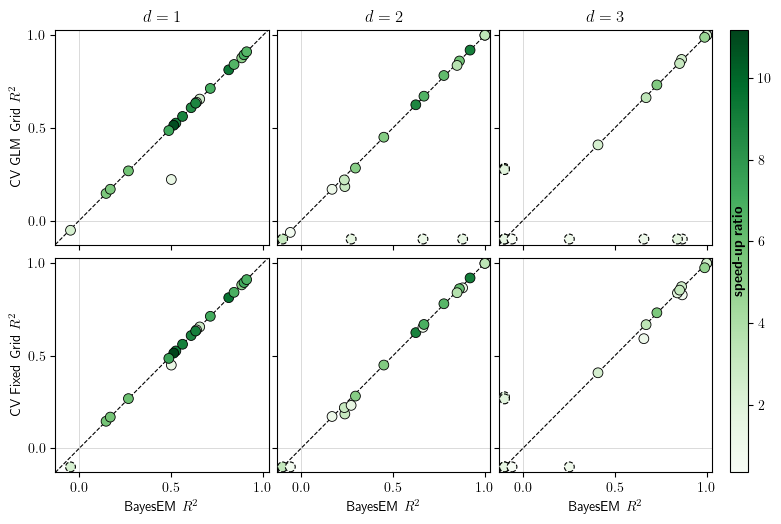

In [19]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp_full, exp_full_d2, exp_full_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp_full, exp_full_d2, exp_full_d3]):
    for row, cv in enumerate([1, 2]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


In [20]:
problems_large = [
    EmpiricalDataProblem('twitter', 'V78'),
    EmpiricalDataProblem('tomshw', 'V97'),
    EmpiricalDataProblem('blog',   'V281'),
    EmpiricalDataProblem('ct_slices', 'reference'),
]

In [21]:
exp_large = EmpiricalDataExperiment(
    problems_large, list(estimators_full.values()),
    n_iterations=30, seed=123,
    est_names=list(estimators_full.keys())).run()
print()

twitter (n=583250, p=77)..............................
tomshw (n=28179, p=96)..............................
blog (n=52397, p=280)..............................
ct_slices (n=53500, p=385)..............................



In [22]:
rows_large = []
for i, problem in enumerate(exp_large.problems):
    em_time = stat_mean(exp_large, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large, 'prediction_r2', est, i) for est in exp_large.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large.ns[i, 0])
    row['n:p']            = int(exp_large.ns[i, 0]) / stat_mean(exp_large, 'number_of_features', 'EM', i)
    rows_large.append(row)
pd.DataFrame(rows_large).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,4.57,77.00,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,3.45,379.57,37450,98.67
2,blog,V281,0.35,0.35,0.35,3.79,275.23,36677,133.26
1,tomshw,V97,0.96,0.96,0.96,3.38,96.00,19725,205.47


In [23]:
problems_large_d2 = [
    EmpiricalDataProblem('twitter',   'V78',       x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('tomshw',    'V97',       x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('blog',      'V281',      x_transforms=[PolynomialExpansion(2)]),
    EmpiricalDataProblem('ct_slices', 'reference', x_transforms=[PolynomialExpansion(2)]),
]

In [24]:
exp_large_d2 = EmpiricalDataExperiment(
    problems_large_d2, list(estimators_full.values()),
    n_iterations=30, seed=123,
    est_names=list(estimators_full.keys())).run()
print()

ValueError: negative dimensions are not allowed

In [ ]:
rows_large_d2 = []
for i, problem in enumerate(exp_large_d2.problems):
    em_time = stat_mean(exp_large_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large_d2, 'prediction_r2', est, i) for est in exp_large_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large_d2.ns[i, 0])
    row['n:p']            = int(exp_large_d2.ns[i, 0]) / stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    rows_large_d2.append(row)
pd.DataFrame(rows_large_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.84,0.87,0.87,4.10,138.00,408275,2958.51
3,ct_slices,reference,0.93,0.93,0.93,2.66,1034.57,37450,36.20
2,blog,V281,0.34,0.34,0.34,2.82,871.30,36677,42.09
1,tomshw,V97,0.93,0.97,0.97,2.29,1339.00,19725,14.73


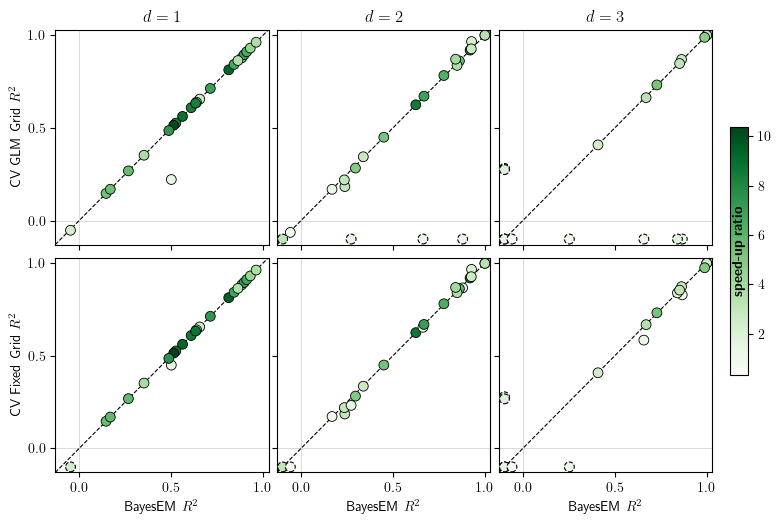

In [ ]:
col_exps = [[exp_full, exp_large], [exp_full_d2, exp_large_d2], [exp_full_d3]]

su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for exps in col_exps for e in exps for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, exps in enumerate(col_exps):
    for row, cv in enumerate([1, 2]):
        scatter_clipped(
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                            / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0) for e in exps]),
            norm, plt.cm.Greens, ax=axes[row, col])

fig.savefig('../output/realdata_r2_by_degree.pdf', bbox_inches='tight')
